# Baseline CNN for the Wefabricate dataset

This notebook contains the baseline part of the assignment. It loads the provided image dataset, defines a small CNN, trains it, and evaluates the result on the test set. The aim here is to get a simple model running from start to finish before hyperparameter tuning is added.


## 1. Load the dataset

The dataset is loaded through the helper function from `support.py`. The printed values are a quick check that the train/test split and image shape match the assignment setup.


In [1]:
from support import load_dataset

train_dataset, test_dataset = load_dataset()

print(len(train_dataset), len(test_dataset))
print(train_dataset.classes)
print(train_dataset[0][0].shape, train_dataset[0][1])

136 34
['ng', 'ok']
torch.Size([3, 60, 30]) 0


## 2. Select the compute device

The notebook uses Apple Silicon acceleration through `mps` when it is available. On a Windows or Linux machine with an NVIDIA GPU it uses `cuda`; otherwise it falls back to CPU.


In [2]:
import platform
import torch

def get_device():
    if torch.backends.mps.is_built() and torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")
print(f"System: {platform.system()}")

Using device: mps
System: Darwin


## 3. Create data loaders

The datasets are wrapped in `DataLoader` objects so training can use mini-batches. `num_workers` is kept at zero because that is usually the most stable option inside notebooks on macOS and Windows.


In [3]:
import torch
from torch.utils.data import DataLoader

batch_size = 16

num_workers = 0
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

sample_images, sample_labels = next(iter(train_loader))
print(sample_images.shape, sample_labels.shape)

torch.Size([16, 3, 60, 30]) torch.Size([16])


## 4. Define the baseline CNN

The baseline model has two convolutional blocks followed by a small fully connected classifier. This is intentionally simple, since it is used as the non-optimized reference model for the later tuning experiments.


In [4]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 15 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN()
with torch.no_grad():
    print(model(sample_images).shape)


torch.Size([16, 2])


## 5. Confirm the active device

This cell only prints the device again, which is useful after restarting the kernel or moving the notebook to another machine.


In [5]:
import platform
import torch

# Device selection is already defined above. Re-run that cell if needed.
print(f"Using device: {device}")
print(f"System: {platform.system()}")

Using device: mps
System: Darwin


## 6. Training function

The training loop keeps track of the loss and accuracy after each epoch. These values are stored so they can be plotted afterwards for the report.


In [6]:
import time
import torch.nn as nn

def train_model(
    model,
    train_loader,
    epochs=50,
    learning_rate=0.001,
    device=None,
):
    if device is None:
        device = get_device()

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    train_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"loss={epoch_loss:.4f} | "
            f"acc={epoch_accuracy:.4f}"
        )

    elapsed = time.time() - start_time
    print(f"Training finished in {elapsed:.1f} seconds on {device}")

    return model, train_losses, train_accuracies

## 7. Train the baseline model

This cell creates a fresh baseline model and trains it with the chosen baseline settings. These settings can be changed here if we want to rerun the same model with a different number of epochs or learning rate.


In [7]:
model = BaselineCNN()

model, train_losses, train_accuracies = train_model(
    model=model,
    train_loader=train_loader,
    epochs=50,
    learning_rate=0.001,
    device=device,
)

Epoch 01/50 | loss=0.6971 | acc=0.5000
Epoch 02/50 | loss=0.6940 | acc=0.5000
Epoch 03/50 | loss=0.6924 | acc=0.5000
Epoch 04/50 | loss=0.6912 | acc=0.5000
Epoch 05/50 | loss=0.6863 | acc=0.5147
Epoch 06/50 | loss=0.6795 | acc=0.5000
Epoch 07/50 | loss=0.6624 | acc=0.6985
Epoch 08/50 | loss=0.6317 | acc=0.7206
Epoch 09/50 | loss=0.5916 | acc=0.6985
Epoch 10/50 | loss=0.5297 | acc=0.8088
Epoch 11/50 | loss=0.5481 | acc=0.6985
Epoch 12/50 | loss=0.4823 | acc=0.7868
Epoch 13/50 | loss=0.4290 | acc=0.8088
Epoch 14/50 | loss=0.3931 | acc=0.8456
Epoch 15/50 | loss=0.3777 | acc=0.8676
Epoch 16/50 | loss=0.3619 | acc=0.8971
Epoch 17/50 | loss=0.3675 | acc=0.8750
Epoch 18/50 | loss=0.3107 | acc=0.9118
Epoch 19/50 | loss=0.3094 | acc=0.8971
Epoch 20/50 | loss=0.3762 | acc=0.8162
Epoch 21/50 | loss=0.3760 | acc=0.8382
Epoch 22/50 | loss=0.3090 | acc=0.8971
Epoch 23/50 | loss=0.3374 | acc=0.8603
Epoch 24/50 | loss=0.2804 | acc=0.8971
Epoch 25/50 | loss=0.2761 | acc=0.9191
Epoch 26/50 | loss=0.2538

## 8. Save the baseline model weights

The trained baseline weights are saved before hyperparameter tuning so this original reference model can be reused and compared with optimized models later.


In [8]:
baseline_weights_path = "baseline_cnn_weights.pth"
torch.save(model.state_dict(), baseline_weights_path)

print(f"Saved baseline model weights to {baseline_weights_path}")

Saved baseline model weights to baseline_cnn_weights.pth


## 9. Plot the training curves

The loss and accuracy curves show how the baseline model behaves during training. These plots can be used in the report section for the non-optimized CNN.


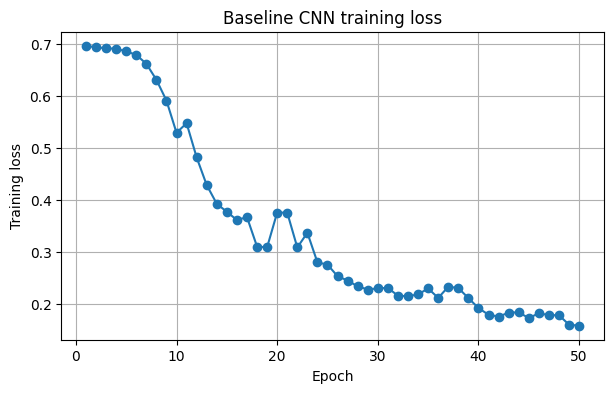

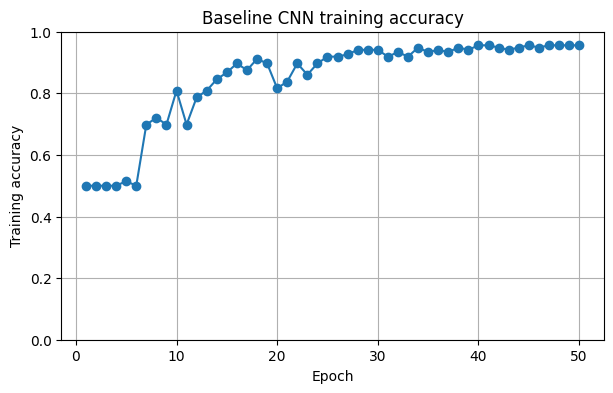

In [9]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Baseline CNN training loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training accuracy")
plt.title("Baseline CNN training accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

## 10. Evaluate on the test set

The test accuracy is computed after training. This is the main baseline score that the optimized models should later be compared against.


In [10]:
def evaluate_model(model, data_loader, device=None):
    if device is None:
        device = get_device()

    model = model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy

test_accuracy = evaluate_model(model, test_loader, device=device)

print(f"Final baseline test accuracy: {test_accuracy:.4f}")

Final baseline test accuracy: 0.8824


## 11. Confusion matrix

The confusion matrix shows how many `ok` and `ng` images were classified correctly or incorrectly. This helps check whether the model is learning both classes instead of mostly predicting one class.


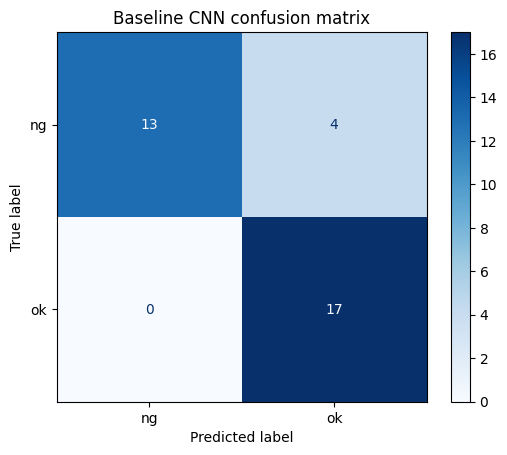

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def get_predictions(model, data_loader, device=None):
    if device is None:
        device = get_device()

    model = model.to(device)
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_predictions

true_labels, predicted_labels = get_predictions(model, test_loader, device=device)

cm = confusion_matrix(true_labels, predicted_labels)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes,
)

display.plot(cmap="Blues")
plt.title("Baseline CNN confusion matrix")
plt.show()